In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
sns.despine()
plt.style.use("seaborn-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc("axes", labelweight="bold", labelsize="large", titleweight="bold", titlesize=14, titlepad=10)

from scipy import stats


import regex as re
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

import xgboost
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

import optuna

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

seed=42


C:\Users\jamr1\miniconda3\envs\este\lib\site-packages\xgboost\compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


<Figure size 432x288 with 0 Axes>

In [3]:
df = pd.read_csv(r'Dataset\train.csv', encoding="ISO-8859-1")

In [4]:
df.head()

,id,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,852,Dell,Inspiron 5767,Notebook,17.3,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R7 M445,Linux,2.83kg,865.0
1,414,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg,928.0
2,283,Lenovo,Ideapad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,6GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,579.0
3,669,Acer,Aspire 3,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,4GB,128GB SSD,Intel HD Graphics 520,Linux,2.1kg,412.0
4,1287,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                912 non-null    int64  
 1   Company           912 non-null    object 
 2   Product           912 non-null    object 
 3   TypeName          912 non-null    object 
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    object 
 6   Cpu               912 non-null    object 
 7   Ram               912 non-null    object 
 8   Memory            912 non-null    object 
 9   Gpu               912 non-null    object 
 10  OpSys             912 non-null    object 
 11  Weight            912 non-null    object 
 12  Price_euros       912 non-null    float64
dtypes: float64(2), int64(1), object(10)
memory usage: 92.8+ KB


In [6]:
df.describe()

,id,Inches,Price_euros
count,912.000000,912.000000,912.000000
mean,653.076754,15.003289,1138.022478
std,378.906322,1.437009,715.342718
min,0.000000,10.100000,174.000000
25%,317.750000,14.000000,615.500000
50%,657.500000,15.600000,989.000000
75%,980.500000,15.600000,1493.350000
max,1302.000000,17.300000,6099.000000


# Data Cleaning 

In [7]:
df = df.rename(columns=str.lower)

In [8]:
df.columns

Index(['id', 'company', 'product', 'typename', 'inches', 'screenresolution',
       'cpu', 'ram', 'memory', 'gpu', 'opsys', 'weight', 'price_euros'],
      dtype='object')

In [9]:
df = df.rename(columns={'price_euros':'price'})

## Check for duplicates

In [10]:
df[df.duplicated()]

,id,company,product,typename,inches,screenresolution,cpu,ram,memory,gpu,opsys,weight,price


# Dataset Cleaning + Feature Engineering

## Laptop ID

In [11]:
df['id']

0       852
1       414
2       283
3       669
4      1287
       ... 
907     256
908     794
909    1057
910    1061
911     373
Name: id, Length: 912, dtype: int64

## Screen resolution

In [12]:
df['screenresolution']

0                              Full HD 1920x1080
1      IPS Panel Full HD / Touchscreen 1920x1080
2                              Full HD 1920x1080
3                                       1366x768
4                                       1366x768
                         ...                    
907                                     1366x768
908           IPS Panel Retina Display 2304x1440
909                                     1366x768
910                  IPS Panel Full HD 1920x1080
911                                     1600x900
Name: screenresolution, Length: 912, dtype: object

### Feature Engineering on Screen resolution

In [13]:
df['resolution'] = df['screenresolution'].str.extract(r'(\d+x\d+)')

In [14]:
df['screentype'] = df['screenresolution'].replace(r'(\d+x\d+)','',regex=True)

In [15]:
df['screentype'] = df['screentype'].replace(r'(Full HD|Quad HD|Quad HD|\+|/|4K Ultra HD)','',regex=True)

In [16]:
df['screentype']

0                               
1       IPS Panel   Touchscreen 
2                               
3                               
4                               
                 ...            
907                             
908    IPS Panel Retina Display 
909                             
910                  IPS Panel  
911                             
Name: screentype, Length: 912, dtype: object

In [17]:
df['touchscreen'] = df['screentype'].str.extract(r'(Touchscreen)')
df['screentype'] = df['screentype'].replace(r'(Touchscreen)','',regex=True)

In [18]:
df['touchscreen'].value_counts()

Touchscreen    141
Name: touchscreen, dtype: int64

In [19]:
df['touchscreen'] = df['touchscreen'].replace('Touchscreen',1)
df['touchscreen'] = df['touchscreen'].replace(np.nan,0)

In [20]:
df['touchscreen'].value_counts()

0.0    771
1.0    141
Name: touchscreen, dtype: int64

In [21]:
df['screentype'].value_counts()

                             386
                             222
IPS Panel                    175
IPS Panel                     56
                              53
IPS Panel Retina Display      12
IPS Panel                      8
Name: screentype, dtype: int64

In [22]:
df['screentype']=df['screentype'].replace(r' ','',regex=True)
df['screentype'].value_counts()

                         661
IPSPanel                 239
IPSPanelRetinaDisplay     12
Name: screentype, dtype: int64

Now we just need to subsitute the blank spaces with a 'NaN'

In [23]:
df['screentype'] = df['screentype'].replace(r'^\s*$', np.nan, regex=True)
df['screentype'].value_counts()

IPSPanel                 239
IPSPanelRetinaDisplay     12
Name: screentype, dtype: int64

In [24]:
df.head()

,id,company,product,typename,inches,screenresolution,cpu,ram,memory,gpu,opsys,weight,price,resolution,screentype,touchscreen
0,852,Dell,Inspiron 5767,Notebook,17.3,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R7 M445,Linux,2.83kg,865.0,1920x1080,NaN,0.0
1,414,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg,928.0,1920x1080,IPSPanel,1.0
2,283,Lenovo,Ideapad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,6GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,579.0,1920x1080,NaN,0.0
3,669,Acer,Aspire 3,Notebook,15.6,1366x768,Intel Core i3 6006U 2GHz,4GB,128GB SSD,Intel HD Graphics 520,Linux,2.1kg,412.0,1366x768,NaN,0.0
4,1287,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0,1366x768,NaN,0.0


In [25]:
df = df.drop('screenresolution', axis=1)

In [26]:
df.head()

,id,company,product,typename,inches,cpu,ram,memory,gpu,opsys,weight,price,resolution,screentype,touchscreen
0,852,Dell,Inspiron 5767,Notebook,17.3,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R7 M445,Linux,2.83kg,865.0,1920x1080,NaN,0.0
1,414,Asus,ZenBook Flip,2 in 1 Convertible,13.3,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg,928.0,1920x1080,IPSPanel,1.0
2,283,Lenovo,Ideapad 320-15IKBN,Notebook,15.6,Intel Core i5 7200U 2.5GHz,6GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,579.0,1920x1080,NaN,0.0
3,669,Acer,Aspire 3,Notebook,15.6,Intel Core i3 6006U 2GHz,4GB,128GB SSD,Intel HD Graphics 520,Linux,2.1kg,412.0,1366x768,NaN,0.0
4,1287,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0,1366x768,NaN,0.0


The newly created columns are as follows:

In [27]:
df['resolution'].value_counts()

1920x1080    585
1366x768     213
3840x2160     28
3200x1800     21
2560x1440     21
1600x900      18
2256x1504      5
2304x1440      5
2880x1800      4
1440x900       3
1920x1200      3
2560x1600      3
2400x1600      2
2160x1440      1
Name: resolution, dtype: int64

In [28]:
df['screentype'].value_counts()

IPSPanel                 239
IPSPanelRetinaDisplay     12
Name: screentype, dtype: int64

In [29]:
df['touchscreen'].value_counts()

0.0    771
1.0    141
Name: touchscreen, dtype: int64

## CPU

In [30]:
df['cpu']

0        Intel Core i7 7500U 2.7GHz
1        Intel Core i5 7200U 2.5GHz
2        Intel Core i5 7200U 2.5GHz
3          Intel Core i3 6006U 2GHz
4        Intel Core i7 6500U 2.5GHz
                   ...             
907    AMD A6-Series A6-9220 2.5GHz
908             Intel Core M 1.2GHz
909       AMD A8-Series 7410 2.2GHz
910     Intel Core i7 6700HQ 2.6GHz
911       AMD A8-Series 7410 2.2GHz
Name: cpu, Length: 912, dtype: object

In [31]:
df['cpu_freq'] = df['cpu'].str.extract(r'(\d+(?:\.\d+)?GHz)') 

With this regex we can extract both float and int frequencies for the CPU

In [32]:
df['cpu_freq'].value_counts()

2.5GHz     213
2.7GHz     119
2.8GHz     108
1.6GHz      95
1.8GHz      59
2.3GHz      55
2.6GHz      53
2GHz        47
1.1GHz      38
2.4GHz      33
2.9GHz      18
3GHz        11
2.0GHz      10
1.44GHz      9
1.2GHz       9
2.2GHz       7
1.5GHz       6
3.6GHz       5
1.3GHz       4
0.9GHz       3
2.50GHz      3
2.1GHz       1
2.70GHz      1
3.2GHz       1
1.0GHz       1
3.1GHz       1
1.9GHz       1
1.92GHz      1
Name: cpu_freq, dtype: int64

Since all the frequencies are in GHz, we can now simply remove 'GHz' and add it to the column name, such that the column can become numerical

In [33]:
df['cpu_freq'] = df['cpu_freq'].str.replace('GHz', '')
df.rename(columns={'cpu_freq': 'cpu_freq(GHz)'}, inplace=True)

In [34]:
df['cpu_freq(GHz)'] = df['cpu_freq(GHz)'].astype(float)

In [35]:
df['cpu']= df['cpu'].str.replace(r'(\d+(?:\.\d+)?GHz)', '', regex=True)

In [36]:
df.head()

,id,company,product,typename,inches,cpu,ram,memory,gpu,opsys,weight,price,resolution,screentype,touchscreen,cpu_freq(GHz)
0,852,Dell,Inspiron 5767,Notebook,17.3,Intel Core i7 7500U,8GB,1TB HDD,AMD Radeon R7 M445,Linux,2.83kg,865.0,1920x1080,NaN,0.0,2.7
1,414,Asus,ZenBook Flip,2 in 1 Convertible,13.3,Intel Core i5 7200U,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg,928.0,1920x1080,IPSPanel,1.0,2.5
2,283,Lenovo,Ideapad 320-15IKBN,Notebook,15.6,Intel Core i5 7200U,6GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,579.0,1920x1080,NaN,0.0,2.5
3,669,Acer,Aspire 3,Notebook,15.6,Intel Core i3 6006U,4GB,128GB SSD,Intel HD Graphics 520,Linux,2.1kg,412.0,1366x768,NaN,0.0,2.0
4,1287,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,Intel Core i7 6500U,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0,1366x768,NaN,0.0,2.5


## RAM

In [37]:
df['ram'] = df['ram'].str.replace('GB', '')

In [38]:
df.rename(columns={'ram': 'ram(GB)'}, inplace=True)

In [39]:
df['ram(GB)'] = df['ram(GB)'].astype(int)

In [40]:
df.head()

,id,company,product,typename,inches,cpu,ram(GB),memory,gpu,opsys,weight,price,resolution,screentype,touchscreen,cpu_freq(GHz)
0,852,Dell,Inspiron 5767,Notebook,17.3,Intel Core i7 7500U,8,1TB HDD,AMD Radeon R7 M445,Linux,2.83kg,865.0,1920x1080,NaN,0.0,2.7
1,414,Asus,ZenBook Flip,2 in 1 Convertible,13.3,Intel Core i5 7200U,8,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg,928.0,1920x1080,IPSPanel,1.0,2.5
2,283,Lenovo,Ideapad 320-15IKBN,Notebook,15.6,Intel Core i5 7200U,6,256GB SSD,Intel HD Graphics 620,Windows 10,2.2kg,579.0,1920x1080,NaN,0.0,2.5
3,669,Acer,Aspire 3,Notebook,15.6,Intel Core i3 6006U,4,128GB SSD,Intel HD Graphics 520,Linux,2.1kg,412.0,1366x768,NaN,0.0,2.0
4,1287,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,Intel Core i7 6500U,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0,1366x768,NaN,0.0,2.5


## Memory

In [41]:
df['memory']

0                  1TB HDD
1                256GB SSD
2                256GB SSD
3                128GB SSD
4                  1TB HDD
              ...         
907              128GB SSD
908    512GB Flash Storage
909                1TB HDD
910                1TB HDD
911              128GB SSD
Name: memory, Length: 912, dtype: object

In [42]:
df['memory'].value_counts()

256GB SSD                        303
1TB HDD                          148
512GB SSD                         87
500GB HDD                         86
128GB SSD +  1TB HDD              67
256GB SSD +  1TB HDD              49
128GB SSD                         46
32GB Flash Storage                26
2TB HDD                           12
64GB Flash Storage                11
1TB SSD                           10
1.0TB Hybrid                       8
512GB SSD +  1TB HDD               8
16GB Flash Storage                 6
256GB SSD +  2TB HDD               6
256GB Flash Storage                6
32GB SSD                           5
180GB SSD                          4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
128GB Flash Storage                2
1TB SSD +  1TB HDD                 2
128GB SSD +  2TB HDD               2
1TB HDD +  1TB HDD                 1
512GB SSD +  1.0TB Hybrid          1
1.0TB HDD                          1
5

In [43]:
df['memory_1']=df['memory']

In [44]:
df['memory_1']=df['memory_1'].str.replace('1.0TB','1TB', regex=True)
df['memory_1']=df['memory_1'].str.replace('1TB','1000GB')
df['memory_1']=df['memory_1'].str.replace('2TB','2000GB')
df['memory_1']=df['memory_1'].str.replace('GB','')
df['memory_1'].value_counts()

256 SSD                         303
1000 HDD                        149
512 SSD                          87
500 HDD                          86
128 SSD +  1000 HDD              67
256 SSD +  1000 HDD              49
128 SSD                          46
32 Flash Storage                 26
2000 HDD                         12
64 Flash Storage                 11
1000 SSD                         10
1000 Hybrid                       8
512 SSD +  1000 HDD               8
16 Flash Storage                  6
256 SSD +  2000 HDD               6
256 Flash Storage                 6
32 SSD                            5
180 SSD                           4
512 SSD +  2000 HDD               3
16 SSD                            3
512 Flash Storage                 2
128 SSD +  2000 HDD               2
1000 SSD +  1000 HDD              2
128 Flash Storage                 2
1000 HDD +  1000 HDD              1
512 SSD +  1000 Hybrid            1
508 Hybrid                        1
64 Flash Storage +  1000 HDD

We transformed the drive capacity to GB

In [45]:
df['memory2']=df['memory_1'].str.replace(r' ','')
df['memory2'].value_counts()

256SSD                    303
1000HDD                   149
512SSD                     87
500HDD                     86
128SSD+1000HDD             67
256SSD+1000HDD             49
128SSD                     46
32FlashStorage             26
2000HDD                    12
64FlashStorage             11
1000SSD                    10
1000Hybrid                  8
512SSD+1000HDD              8
16FlashStorage              6
256SSD+2000HDD              6
256FlashStorage             6
32SSD                       5
180SSD                      4
512SSD+2000HDD              3
16SSD                       3
512FlashStorage             2
128SSD+2000HDD              2
1000SSD+1000HDD             2
128FlashStorage             2
1000HDD+1000HDD             1
512SSD+1000Hybrid           1
508Hybrid                   1
64FlashStorage+1000HDD      1
128HDD                      1
512SSD+256SSD               1
32HDD                       1
256SSD+500HDD               1
8SSD                        1
Name: memo

In [46]:
memory_1=[]
memory_2=[]
for i in df['memory2']:
    if len(re.findall(r'\+',i))==1: # DOUBLE DRIVE
        one=re.findall(r'(\w+)',i)
        memory_1.append(one[0])
        memory_2.append(one[1])
    else: # SINGLE DRIVE
        one=re.findall(r'(\w+)',i)
        memory_1.append(one[0])
        memory_2.append('NaN')


In [47]:
memory_1_gb=[]
memory_1_type=[]
for i in memory_1:
    memory_1_type.append(re.findall(r'(\D\w+)',i)[0])
    memory_1_gb.append(re.findall(r'(\d+)',i)[0])

### Memory 2

In [48]:
memory_2_gb=[]
memory_2_type=[]
for i in memory_2:
    if i != 'NaN':
        memory_2_type.append(re.findall(r'(\D\w+)',i)[0])
        memory_2_gb.append(re.findall(r'(\d+)',i)[0])
    else:
        memory_2_type.append('NaN')
        memory_2_gb.append(0)

In [49]:
df['memory_1_sto(GB)'] = memory_1_gb
df['memory_1_type'] = memory_1_type
df['memory_2_sto(GB)'] = memory_2_gb
df['memory_2_type'] = memory_2_type

In [50]:
df['memory_1_sto(GB)'] = df['memory_1_sto(GB)'].astype(float)
df['memory_2_sto(GB)'] = df['memory_2_sto(GB)'].astype(float)

In [51]:
df.head()

,id,company,product,typename,inches,cpu,ram(GB),memory,gpu,opsys,...,resolution,screentype,touchscreen,cpu_freq(GHz),memory_1,memory2,memory_1_sto(GB),memory_1_type,memory_2_sto(GB),memory_2_type
0,852,Dell,Inspiron 5767,Notebook,17.3,Intel Core i7 7500U,8,1TB HDD,AMD Radeon R7 M445,Linux,...,1920x1080,NaN,0.0,2.7,1000 HDD,1000HDD,1000.0,HDD,0.0,NaN
1,414,Asus,ZenBook Flip,2 in 1 Convertible,13.3,Intel Core i5 7200U,8,256GB SSD,Intel HD Graphics 620,Windows 10,...,1920x1080,IPSPanel,1.0,2.5,256 SSD,256SSD,256.0,SSD,0.0,NaN
2,283,Lenovo,Ideapad 320-15IKBN,Notebook,15.6,Intel Core i5 7200U,6,256GB SSD,Intel HD Graphics 620,Windows 10,...,1920x1080,NaN,0.0,2.5,256 SSD,256SSD,256.0,SSD,0.0,NaN
3,669,Acer,Aspire 3,Notebook,15.6,Intel Core i3 6006U,4,128GB SSD,Intel HD Graphics 520,Linux,...,1366x768,NaN,0.0,2.0,128 SSD,128SSD,128.0,SSD,0.0,NaN
4,1287,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,Intel Core i7 6500U,6,1TB HDD,AMD Radeon R5 M330,Windows 10,...,1366x768,NaN,0.0,2.5,1000 HDD,1000HDD,1000.0,HDD,0.0,NaN


In [52]:
df=df.drop(['memory_1','memory2','memory'], axis=1)

In [53]:
df = df.replace({'NaN': np.nan})

In [54]:
df.head()

,id,company,product,typename,inches,cpu,ram(GB),gpu,opsys,weight,price,resolution,screentype,touchscreen,cpu_freq(GHz),memory_1_sto(GB),memory_1_type,memory_2_sto(GB),memory_2_type
0,852,Dell,Inspiron 5767,Notebook,17.3,Intel Core i7 7500U,8,AMD Radeon R7 M445,Linux,2.83kg,865.0,1920x1080,NaN,0.0,2.7,1000.0,HDD,0.0,NaN
1,414,Asus,ZenBook Flip,2 in 1 Convertible,13.3,Intel Core i5 7200U,8,Intel HD Graphics 620,Windows 10,1.27kg,928.0,1920x1080,IPSPanel,1.0,2.5,256.0,SSD,0.0,NaN
2,283,Lenovo,Ideapad 320-15IKBN,Notebook,15.6,Intel Core i5 7200U,6,Intel HD Graphics 620,Windows 10,2.2kg,579.0,1920x1080,NaN,0.0,2.5,256.0,SSD,0.0,NaN
3,669,Acer,Aspire 3,Notebook,15.6,Intel Core i3 6006U,4,Intel HD Graphics 520,Linux,2.1kg,412.0,1366x768,NaN,0.0,2.0,128.0,SSD,0.0,NaN
4,1287,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,Intel Core i7 6500U,6,AMD Radeon R5 M330,Windows 10,2.19kg,764.0,1366x768,NaN,0.0,2.5,1000.0,HDD,0.0,NaN


## Weight

In [55]:
df['weight'].value_counts()

2.2kg     84
2.1kg     41
2.4kg     26
2kg       26
2.5kg     26
          ..
3.4kg      1
1.78kg     1
2.54kg     1
1.99kg     1
4kg        1
Name: weight, Length: 167, dtype: int64

In [56]:
df['weight'].str.contains('kg').sum()

912

In [57]:
df['weight'] = df['weight'].str.replace('kg','').astype(float)

In [58]:
df.rename(columns={'weight': 'weight(kg)'}, inplace=True)

In [59]:
df.head()

,id,company,product,typename,inches,cpu,ram(GB),gpu,opsys,weight(kg),price,resolution,screentype,touchscreen,cpu_freq(GHz),memory_1_sto(GB),memory_1_type,memory_2_sto(GB),memory_2_type
0,852,Dell,Inspiron 5767,Notebook,17.3,Intel Core i7 7500U,8,AMD Radeon R7 M445,Linux,2.83,865.0,1920x1080,NaN,0.0,2.7,1000.0,HDD,0.0,NaN
1,414,Asus,ZenBook Flip,2 in 1 Convertible,13.3,Intel Core i5 7200U,8,Intel HD Graphics 620,Windows 10,1.27,928.0,1920x1080,IPSPanel,1.0,2.5,256.0,SSD,0.0,NaN
2,283,Lenovo,Ideapad 320-15IKBN,Notebook,15.6,Intel Core i5 7200U,6,Intel HD Graphics 620,Windows 10,2.20,579.0,1920x1080,NaN,0.0,2.5,256.0,SSD,0.0,NaN
3,669,Acer,Aspire 3,Notebook,15.6,Intel Core i3 6006U,4,Intel HD Graphics 520,Linux,2.10,412.0,1366x768,NaN,0.0,2.0,128.0,SSD,0.0,NaN
4,1287,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,Intel Core i7 6500U,6,AMD Radeon R5 M330,Windows 10,2.19,764.0,1366x768,NaN,0.0,2.5,1000.0,HDD,0.0,NaN


## CPU and GPU manifacturing companies

In [60]:
df['cpu_brand'] = df['cpu'].str.extract(r'^(\w+)')
df['cpu_brand'].value_counts()

Intel    866
AMD       46
Name: cpu_brand, dtype: int64

In [61]:
df[df['cpu_brand']=='Samsung']

,id,company,product,typename,inches,cpu,ram(GB),gpu,opsys,weight(kg),price,resolution,screentype,touchscreen,cpu_freq(GHz),memory_1_sto(GB),memory_1_type,memory_2_sto(GB),memory_2_type,cpu_brand


In [62]:
df['gpu_brand'] = df['gpu'].str.extract(r'^(\w+)')
df['gpu_brand'].value_counts()

Intel     512
Nvidia    275
AMD       125
Name: gpu_brand, dtype: int64

There is one laptop with an ARM gpu, which is it?

In [63]:
df[df['gpu_brand']=='ARM']

,id,company,product,typename,inches,cpu,ram(GB),gpu,opsys,weight(kg),...,resolution,screentype,touchscreen,cpu_freq(GHz),memory_1_sto(GB),memory_1_type,memory_2_sto(GB),memory_2_type,cpu_brand,gpu_brand


It's the same laptop with the samsung CPU.

In [64]:
df.head()

,id,company,product,typename,inches,cpu,ram(GB),gpu,opsys,weight(kg),...,resolution,screentype,touchscreen,cpu_freq(GHz),memory_1_sto(GB),memory_1_type,memory_2_sto(GB),memory_2_type,cpu_brand,gpu_brand
0,852,Dell,Inspiron 5767,Notebook,17.3,Intel Core i7 7500U,8,AMD Radeon R7 M445,Linux,2.83,...,1920x1080,NaN,0.0,2.7,1000.0,HDD,0.0,NaN,Intel,AMD
1,414,Asus,ZenBook Flip,2 in 1 Convertible,13.3,Intel Core i5 7200U,8,Intel HD Graphics 620,Windows 10,1.27,...,1920x1080,IPSPanel,1.0,2.5,256.0,SSD,0.0,NaN,Intel,Intel
2,283,Lenovo,Ideapad 320-15IKBN,Notebook,15.6,Intel Core i5 7200U,6,Intel HD Graphics 620,Windows 10,2.20,...,1920x1080,NaN,0.0,2.5,256.0,SSD,0.0,NaN,Intel,Intel
3,669,Acer,Aspire 3,Notebook,15.6,Intel Core i3 6006U,4,Intel HD Graphics 520,Linux,2.10,...,1366x768,NaN,0.0,2.0,128.0,SSD,0.0,NaN,Intel,Intel
4,1287,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,Intel Core i7 6500U,6,AMD Radeon R5 M330,Windows 10,2.19,...,1366x768,NaN,0.0,2.5,1000.0,HDD,0.0,NaN,Intel,AMD


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                912 non-null    int64  
 1   company           912 non-null    object 
 2   product           912 non-null    object 
 3   typename          912 non-null    object 
 4   inches            912 non-null    float64
 5   cpu               912 non-null    object 
 6   ram(GB)           912 non-null    int32  
 7   gpu               912 non-null    object 
 8   opsys             912 non-null    object 
 9   weight(kg)        912 non-null    float64
 10  price             912 non-null    float64
 11  resolution        912 non-null    object 
 12  screentype        251 non-null    object 
 13  touchscreen       912 non-null    float64
 14  cpu_freq(GHz)     912 non-null    float64
 15  memory_1_sto(GB)  912 non-null    float64
 16  memory_1_type     912 non-null    object 
 1

Now the dataset looks clean and ready to be explored

In [66]:
df.to_csv('laptop-clean.csv', index=False)

# Exploratory Data Analysis EDA

In [67]:
df1=pd.read_csv('laptop-clean.csv')
df1.head()

,id,company,product,typename,inches,cpu,ram(GB),gpu,opsys,weight(kg),...,resolution,screentype,touchscreen,cpu_freq(GHz),memory_1_sto(GB),memory_1_type,memory_2_sto(GB),memory_2_type,cpu_brand,gpu_brand
0,852,Dell,Inspiron 5767,Notebook,17.3,Intel Core i7 7500U,8,AMD Radeon R7 M445,Linux,2.83,...,1920x1080,NaN,0.0,2.7,1000.0,HDD,0.0,NaN,Intel,AMD
1,414,Asus,ZenBook Flip,2 in 1 Convertible,13.3,Intel Core i5 7200U,8,Intel HD Graphics 620,Windows 10,1.27,...,1920x1080,IPSPanel,1.0,2.5,256.0,SSD,0.0,NaN,Intel,Intel
2,283,Lenovo,Ideapad 320-15IKBN,Notebook,15.6,Intel Core i5 7200U,6,Intel HD Graphics 620,Windows 10,2.20,...,1920x1080,NaN,0.0,2.5,256.0,SSD,0.0,NaN,Intel,Intel
3,669,Acer,Aspire 3,Notebook,15.6,Intel Core i3 6006U,4,Intel HD Graphics 520,Linux,2.10,...,1366x768,NaN,0.0,2.0,128.0,SSD,0.0,NaN,Intel,Intel
4,1287,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,Intel Core i7 6500U,6,AMD Radeon R5 M330,Windows 10,2.19,...,1366x768,NaN,0.0,2.5,1000.0,HDD,0.0,NaN,Intel,AMD


Moreover, we will create a new dataframe df2 which will contain a further cleaned version of df (without outliers etc..)

In [68]:
df_clean=df1.copy()

In [69]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                912 non-null    int64  
 1   company           912 non-null    object 
 2   product           912 non-null    object 
 3   typename          912 non-null    object 
 4   inches            912 non-null    float64
 5   cpu               912 non-null    object 
 6   ram(GB)           912 non-null    int64  
 7   gpu               912 non-null    object 
 8   opsys             912 non-null    object 
 9   weight(kg)        912 non-null    float64
 10  price             912 non-null    float64
 11  resolution        912 non-null    object 
 12  screentype        251 non-null    object 
 13  touchscreen       912 non-null    float64
 14  cpu_freq(GHz)     912 non-null    float64
 15  memory_1_sto(GB)  912 non-null    float64
 16  memory_1_type     912 non-null    object 
 1

In [70]:
def num_plot(df, col, title, symb):
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8,5),gridspec_kw={"height_ratios": (.2, .8)})
    ax[0].set_title(title,fontsize=18)
    sns.boxplot(x=col, data=df, ax=ax[0])
    ax[0].set(yticks=[])
    sns.histplot(x=col, data=df, ax=ax[1])
    ax[1].set_xlabel(col, fontsize=16)
    plt.axvline(df[col].mean(), color='darkgreen', linewidth=2.2, label='mean=' + str(np.round(df[col].mean(),1)) + symb)
    plt.axvline(df[col].median(), color='red', linewidth=2.2, label='median='+ str(np.round(df[col].median(),1)) + symb)
    plt.axvline(df[col].mode()[0], color='purple', linewidth=2.2, label='mode='+ str(df[col].mode()[0]) + symb)
    plt.legend(bbox_to_anchor=(1, 1.03), ncol=1, fontsize=17, fancybox=True, shadow=True, frameon=True)
    plt.tight_layout()
    plt.show()

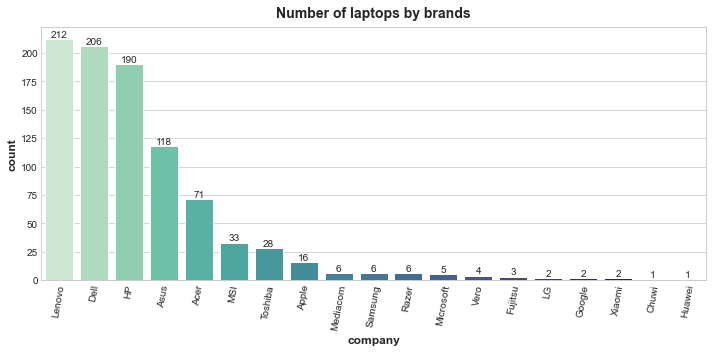

In [71]:
fig, ax  = plt.subplots(figsize=(10,5))
ax=sns.countplot(x='company', data=df, palette='mako_r', order = df['company'].value_counts().index)
ax.set_xticklabels(ax.get_xticklabels(), rotation=80)
ax.bar_label(ax.containers[0])
plt.title('Number of laptops by brands')
plt.show()

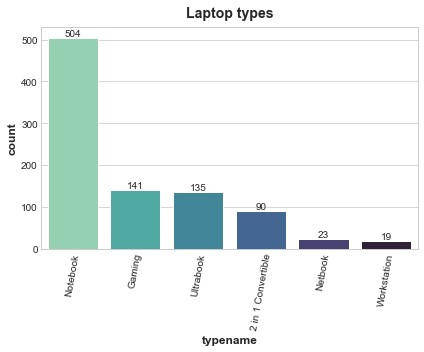

In [72]:
fig, ax  = plt.subplots(figsize=(6,5))
ax=sns.countplot(x='typename', data=df,palette='mako_r', order = df['typename'].value_counts().index)
ax.set_xticklabels(ax.get_xticklabels(), rotation=80);
ax.bar_label(ax.containers[0])
plt.title('Laptop types')
plt.show()

In [73]:
print('Most laptops are notebooks, which make {:.2f}% of the total laptops'.format(len(df[df['typename']=='Notebook'])*100/len(df)))

Most laptops are notebooks, which make 55.26% of the total laptops


# Which size is the most popular?

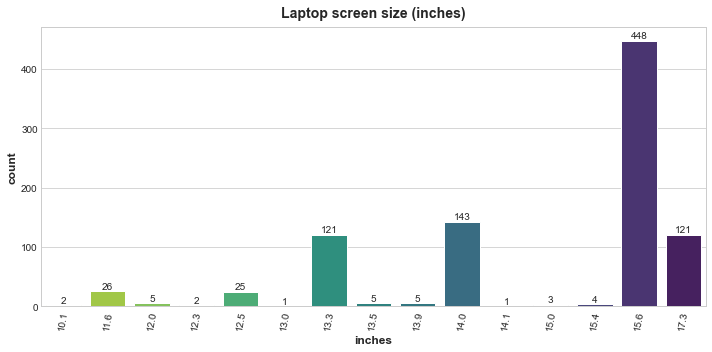

In [74]:
fig, ax  = plt.subplots(figsize=(10,5))
ax=sns.countplot(x='inches', data=df, palette='viridis_r')
ax.set_xticklabels(ax.get_xticklabels(), rotation=80);
ax.bar_label(ax.containers[0])
plt.title('Laptop screen size (inches)')
plt.show()

In [75]:
print('Most laptops have 15.6 inches, which make {:.2f}% of the total laptops'.format(len(df[df['inches']==15.6])*100/len(df)))

Most laptops have 15.6 inches, which make 49.12% of the total laptops


In [76]:
inches_list = df['inches'].value_counts().index[:6].tolist()
inches_list

[15.6, 14.0, 17.3, 13.3, 11.6, 12.5]

In [77]:
df_clean = df_clean[df_clean['inches'].isin(inches_list)]

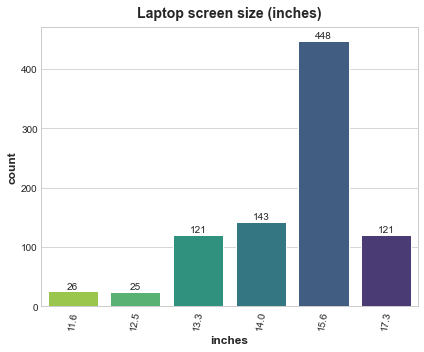

In [78]:
fig, ax  = plt.subplots(figsize=(6,5))
ax=sns.countplot(x='inches', data=df_clean, palette='viridis_r')
ax.set_xticklabels(ax.get_xticklabels(), rotation=80);
ax.bar_label(ax.containers[0])
plt.title('Laptop screen size (inches)')
plt.show()

In [79]:
print('We removed {} outliers!'.format(len(df)-len(df_clean)))

We removed 28 outliers!


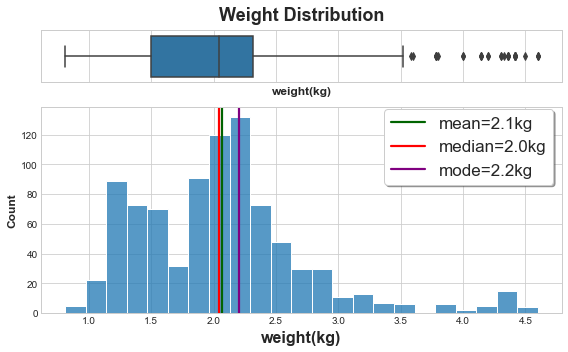

In [80]:
num_plot(df_clean, 'weight(kg)', 'Weight Distribution','kg')

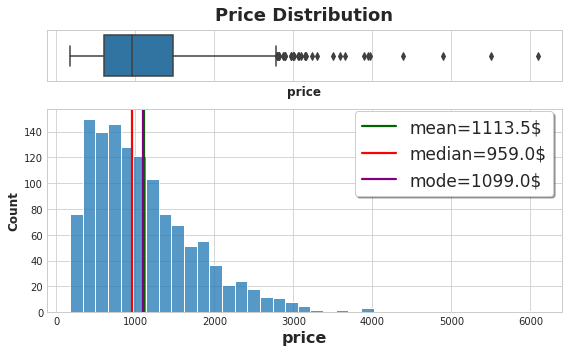

In [235]:
num_plot(df_clean, 'price', 'Price Distribution','$')

It looks like there are some laptops with a price over 3000 euros!

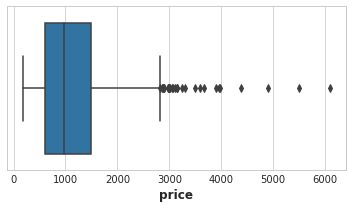

In [236]:
fig, ax  = plt.subplots(figsize=(5,3))
ax=sns.boxplot(x='price', data=df)

<AxesSubplot:xlabel='typename', ylabel='price'>

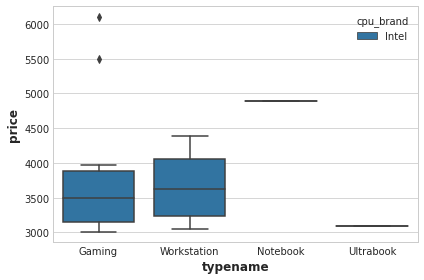

In [237]:
sns.boxplot(x='typename', y='price', data=df[df['price']>3000], hue='cpu_brand')

It looks like most of them are Gaming PCs or Workstations with intel CPU. There is also one Notebook with a price close to 5000 euros and 2 outlier values for Gaming Pc, with a price close to 5500 euros and 6000 euros

In [238]:
df[df['price']>4500]

,company,product,typename,inches,cpu,ram(GB),gpu,opsys,weight(kg),price,resolution,screentype,touchscreen,cpu_freq(GHz),memory_1_sto(GB),memory_1_type,memory_2_sto(GB),memory_2_type,cpu_brand,gpu_brand
196,Razer,Blade Pro,Gaming,17.3,Intel Core i7 7820HK,32,Nvidia GeForce GTX 1080,Windows 10,3.49,6099.0,3840x2160,NaN,1.0,2.9,1000.0,SSD,0.0,NaN,Intel,Nvidia
610,Lenovo,Thinkpad P51,Notebook,15.6,Intel Xeon E3-1535M v6,32,Nvidia Quadro M2200M,Windows 10,2.50,4899.0,3840x2160,IPSPanel,0.0,3.1,1000.0,SSD,0.0,NaN,Intel,Nvidia
830,Razer,Blade Pro,Gaming,17.3,Intel Core i7 7820HK,32,Nvidia GeForce GTX 1080,Windows 10,3.49,5499.0,3840x2160,NaN,1.0,2.9,512.0,SSD,0.0,NaN,Intel,Nvidia


The expensive notebook is the Lenovo Thinkpad P51, with an Intel XEON CPU and Nvidia Quadro GPU!

## How is RAM distributed among the laptops?

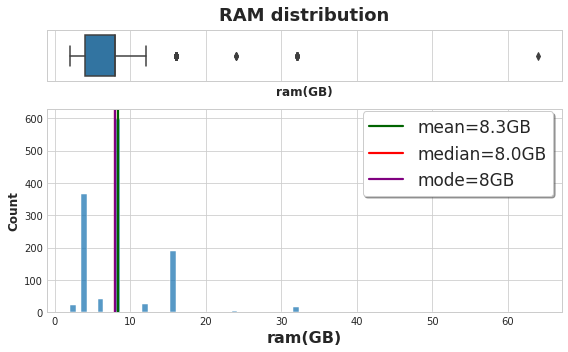

In [239]:
num_plot(df_clean, 'ram(GB)','RAM distribution','GB')

In [240]:
print('Most laptops have 8 GB RAM, which make {:.2f}% of the total laptops'.format(len(df[df['ram(GB)']==8])*100/len(df)))

Most laptops have 8 GB RAM, which make 47.54% of the total laptops


## How is CPU frequency distributed among the laptops?

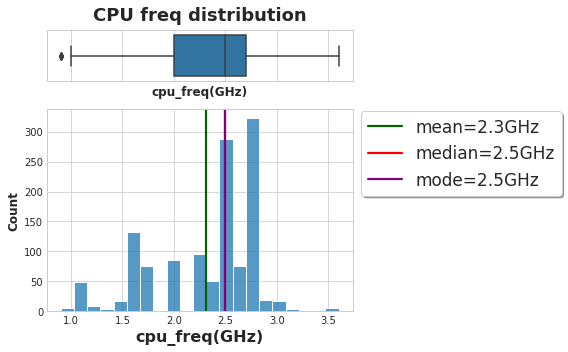

In [241]:
num_plot(df_clean, 'cpu_freq(GHz)','CPU freq distribution','GHz')

In [242]:
print('Most laptops have 2.5 GHz CPU, which make {}% of the total laptops'.format(np.round(len(df[df['cpu_freq(GHz)']==2.5])*100/len(df),2)))

Most laptops have 2.5 GHz CPU, which make 22.5% of the total laptops


## How is Hard Drive capacity distributed among the laptops?

First, we will analyze the first hard drive storage capacity

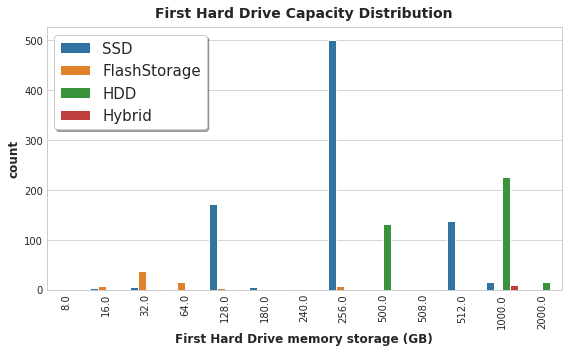

In [243]:
fig, ax  = plt.subplots(figsize=(8,5))
ax=sns.countplot(x='memory_1_sto(GB)', data=df, hue='memory_1_type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel('First Hard Drive memory storage (GB)')
plt.title('First Hard Drive Capacity Distribution')
plt.legend(loc='upper left', ncol=1, fontsize=15, fancybox=True, shadow=True, frameon=True)
plt.show()

Most PCs have 256 GB of storage, which is for the most part SSD. Moreover, for storage of 1 TB or higher, most of them are HDD.

### Second hard Drive analysis

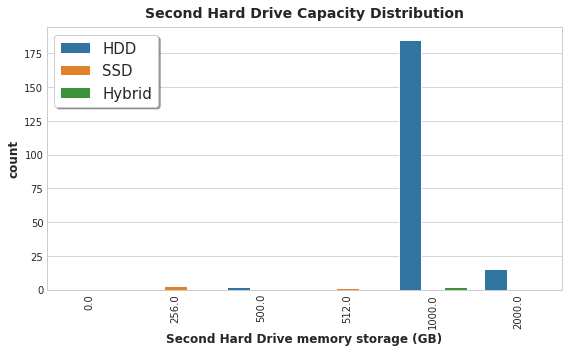

In [244]:
fig, ax  = plt.subplots(figsize=(8,5))
ax=sns.countplot(x='memory_2_sto(GB)', data=df, hue='memory_2_type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel('Second Hard Drive memory storage (GB)')
plt.title('Second Hard Drive Capacity Distribution')
plt.legend(loc='upper left', ncol=1, fontsize=15, fancybox=True, shadow=True, frameon=True)
plt.show()

Most of second hard drive storages are 1 TB HDD disks

Until now we analyzed each single feature at a time, in the following we will analyze these features together to find useful insghts about the data.

# Multivariate outliers detection

## Price vs RAM

We define a custom plot function, which computes, returns and plots a linear regression line.

In [245]:
def lr_plot(df, col_x, col_y, leg):
    slope, intercept, r_value, p_value, std_err = stats.linregress(df[col_x],df[col_y])
    sns.regplot(x=col_x, y = col_y, data=df, color='#0d98ba', line_kws={'label':"y={0:.1f}x+{1:.1f}".format(slope,intercept)})
    plt.legend(loc=leg, ncol=1, fontsize=15, fancybox=True, shadow=True, frameon=True)
    plt.title(col_y + ' VS ' + col_x)
    plt.show()

    return slope, intercept

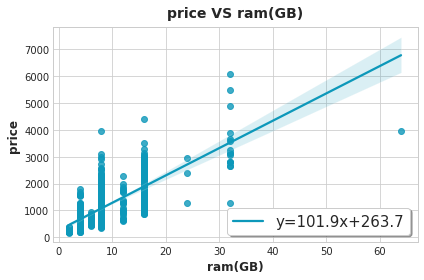

In [246]:
slope, intercept = lr_plot(df_clean,'ram(GB)','price', 'lower right')

It looks like there is an outlier value

In [247]:
df_clean[df_clean['ram(GB)']>60]

,company,product,typename,inches,cpu,ram(GB),gpu,opsys,weight(kg),price,resolution,screentype,touchscreen,cpu_freq(GHz),memory_1_sto(GB),memory_1_type,memory_2_sto(GB),memory_2_type,cpu_brand,gpu_brand
1066,Asus,ROG G701VO,Gaming,17.3,Intel Core i7 6820HK,64,Nvidia GeForce GTX 980,Windows 10,3.58,3975.0,1920x1080,IPSPanel,0.0,2.7,1000.0,SSD,0.0,NaN,Intel,Nvidia


The outlier value is a very high end gaming ASUS pc. We can drop it.

In [248]:
df_clean = df_clean[df_clean['ram(GB)']<60]

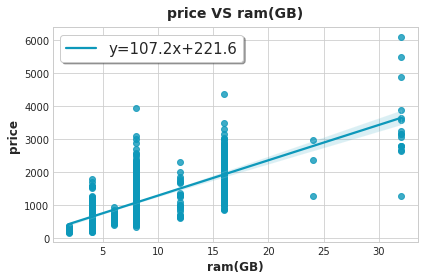

In [249]:
slope, intercept = lr_plot(df_clean,'ram(GB)','price', 'upper left')

By removing the outlier value we can see that the slope increases and the intercept decreases.

According to the slope, every GB of RAM added on the PC adds roughly 107$ to the laptop value.

## Price vs CPU Frequency

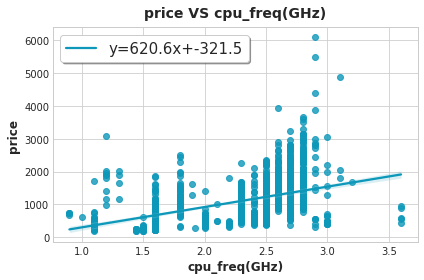

In [250]:
slope, intercept = lr_plot(df_clean,'cpu_freq(GHz)','price', 'upper left')

We can see a positive trend between price and the CPU frequency, with no obvious outliers. <br>
 It is also interesting noticing that the intercept is negative: a PC with 0 Ghz would cost -321.5 dollars according to this linear regression, which of course, it is not possible.

## Price vs inches

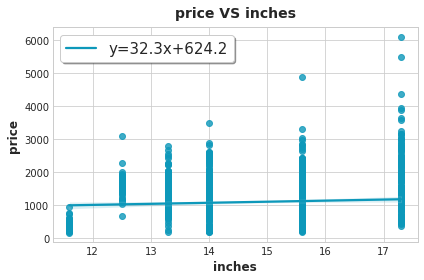

In [251]:
slope, intercept = lr_plot(df_clean,'inches','price', 'upper left')

The regression line is almost flat, with slope=32 $/inches, meaning that PCs with higher screen inches slightly tends to be more expensive.

## Weight vs Inches

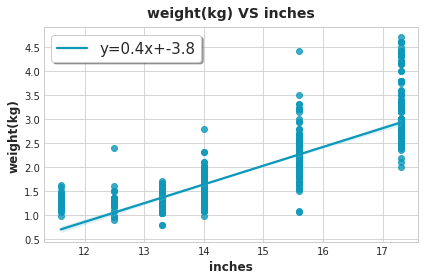

In [252]:
slope, intercept = lr_plot(df_clean,'inches','weight(kg)', 'upper left')

As expected, PCs with bigger screens are heavier. In particular, on average, for every additional inch the pc is 400g heavier.

# Price VS CPU brand by GPU brand

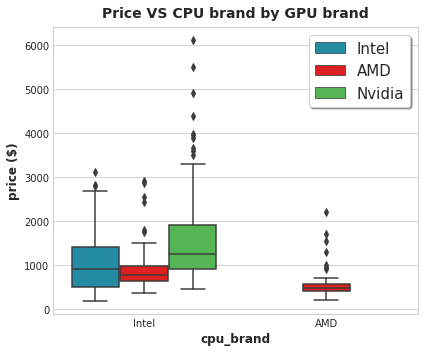

In [253]:
cpu_palette = {'Intel':'#0d98ba', 'AMD':'#FF0000', 'Nvidia':'#46C646'}
fig, ax = plt.subplots(figsize=(6,5))
sns.boxplot(x='cpu_brand', y='price', data=df, hue='gpu_brand', palette=cpu_palette)
ax.set_title('Price vs CPU brand by GPU brand')
plt.ylabel('price ($)')
plt.legend(loc='upper right', ncol=1, fontsize=15, fancybox=True, shadow=True, frameon=True)
plt.title('Price VS CPU brand by GPU brand')
plt.show()

Insights from this plot:
- Laptops with Intel CPUs are more expensive.
- Laptops with an AMD CPUs also hahave and AMD GPUs
- Laptops with Nvidia GPUs are more expensive.

# Which are the TOP 15 most common GPUs?

In [254]:
gpu_list = df_clean['gpu'].value_counts()[:15].index.tolist()

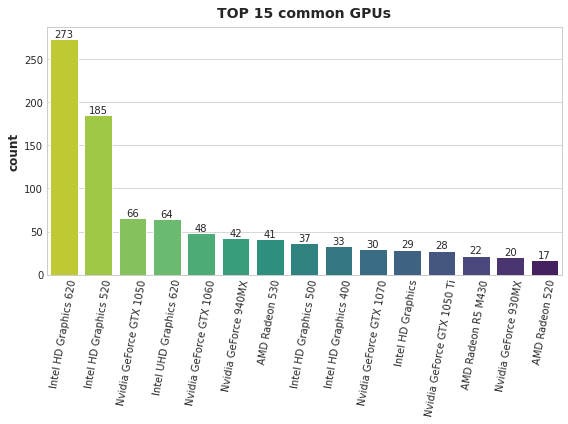

In [255]:
plt.figure(figsize=(8,6))
ax=sns.countplot(x='gpu', data=df_clean[df_clean['gpu'].isin(gpu_list)], order = gpu_list, palette='viridis_r')
plt.xticks(rotation=80);
ax.bar_label(ax.containers[0])
plt.title('TOP 15 common GPUs')
plt.xlabel('')
plt.show()

The 2 most common GPUs are integrated Intel GPUs HD Graphics 620 and 520, while the third one is the Nvidia GTX1050. 

# Which are the TOP 15 most common CPUs?

In [256]:
cpu_list = df_clean['cpu'].value_counts()[:15].index.tolist()

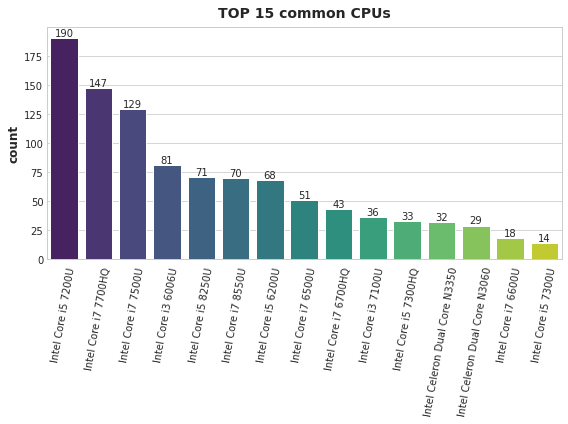

In [257]:
plt.figure(figsize=(8,6))
ax=sns.countplot(x='cpu', data=df_clean[df_clean['cpu'].isin(cpu_list)], order = cpu_list, palette='viridis')
plt.xticks(rotation=80);
ax.bar_label(ax.containers[0])
plt.title('TOP 15 common CPUs')
plt.xlabel('')
plt.show()

- All the TOP 15 most common CPUs are from Intel.
- The most common CPU is the Intel i5 7200U, second is i7 7700HQ and third is i7 7500U.
- Out of the 15 CPUs, 10 are series 'U' (low voltage) , 3 are series 'HQ' (high performance) 10 and 2 are Celerons (low-end).

# What is the average price of laptops by company?

As seen previously, there are some companies which have just few laptops in the dataset:

In [258]:
df['company'].value_counts()

Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        8
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: company, dtype: int64

In particular, there are companies with less than 10 laptops in the dataset, which is a very low number from which we can extract statistical results. <br>
For this reason, we will consider only laptops with at least 20 laptops in the dataset.

In [259]:
company_list = df['company'].value_counts().index[:8].tolist()
company_list

['Dell', 'Lenovo', 'HP', 'Asus', 'Acer', 'MSI', 'Toshiba', 'Apple']

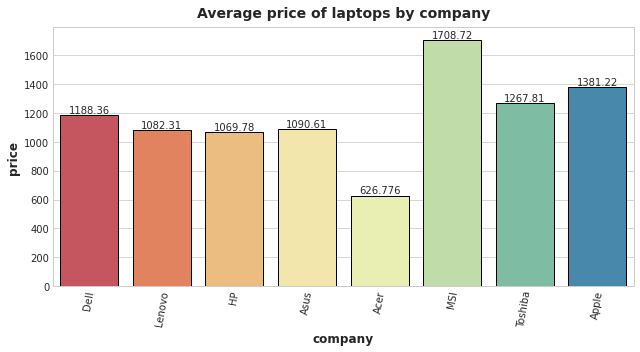

In [260]:
plt.figure(figsize=(9,5))
ax=sns.barplot(x='company', y='price', data=df_clean[df_clean['company'].isin(company_list)],
                order=company_list, 
                palette='Spectral', 
                ci=False,
                edgecolor="black")
plt.xticks(rotation=80);
ax.bar_label(ax.containers[0])
plt.title('Average price of laptops by company')
plt.show()

- MSI laptops are on average the most expensive, with an average price of 1708.72$.
- Apple laptops are the second most expensive laptops and Toshiba's are 3rd.
- Acer are the cheapest, with an average price of 626$
- Laptops from Dell, Lenovo, HP and Asus have, on average, a price around 1000$.

## Correlation Matrix

The correlation matrix can give some useful informations about the linear correlation between the numerical features

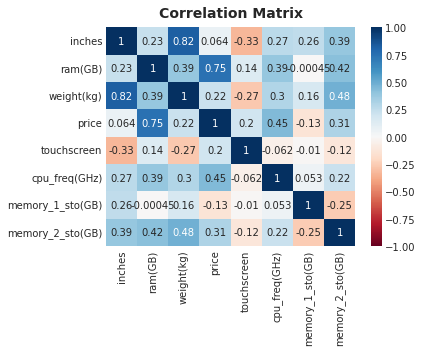

In [261]:
plt.figure(figsize=(6,5))
sns.heatmap(df_clean.corr(), cmap='RdBu', annot=True, vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

Insights from the correlation matrix:
- RAM has a high positive correlation with price (+0.75): more expensive laptops tends to have a higher pric
- CPU Freq has a quite moderate positive correlation with the price (+0.45) 
- Inches and Weight have a high positive correlation (+0.82) since laptops with bigger screens tend to be heavier.

# Data preparation for ML modeling

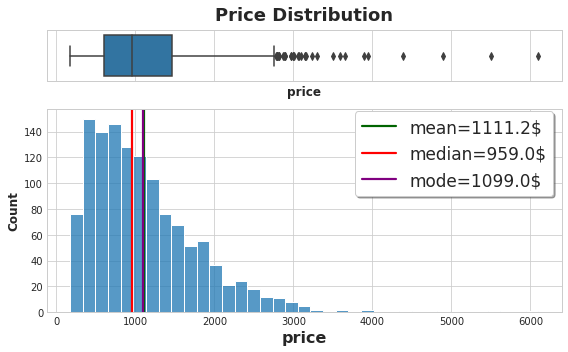

In [262]:
num_plot(df_clean, 'price', 'Price Distribution','$')

For prediction, we will use the cleaned dataframe 'df_clean'

In [263]:
df1=df_clean.copy()

Moreover, since the target variable 'price' is right skewed, we will log transform it to improve the prediction performance of the algorithms.

In [264]:
df1['price']=np.log(df1['price'])

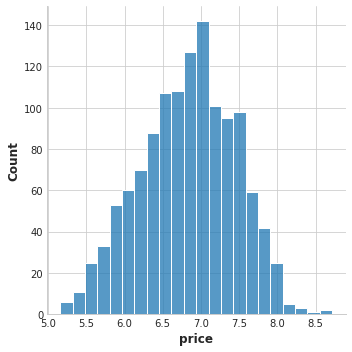

In [265]:
sns.displot(df1['price'])

Indeed now the distribution looks more gaussian.
EDIT: By log-transforming the target variable 'price', I could achieve R2=0.93 with XGBoost! Without log transforming, R2 was closer to 0.88.

In [266]:
df1=df1.fillna('NaN')

## Categorical features encoding

The categorical columns ('company','product','typename','cpu','gpu','opsys','resolution','screentype','resolution','memory_1_type','memory_2_type','gpu_brand','cpu_brand') will be now encoded. <br>
An encoding by one hot encoding would be preferrable in this case since there is not a order/hierarchy among the different categories for each variable, but this would lead to a very high number of columns (around 900), which is close to the number of total rows (1000).<br>
So, if we had more data a OHE encoding would be preferrable, but in case a Label Encoding will be performed to keep the number of features lower.

In [267]:
catCols =  ['company','product','typename','cpu','gpu','opsys','resolution','screentype','resolution','memory_1_type','memory_2_type','gpu_brand','cpu_brand']

In [268]:
#One hot encoding
print('Dataframe encoded by OHE dimension : ', pd.get_dummies(df1, columns=catCols, drop_first=True).shape)

Dataframe encoded by OHE dimension :  (1261, 849)


In [269]:
#Label encoding
en = LabelEncoder()
for cols in catCols:
    df1[cols] = en.fit_transform(df1[cols])
print('Dataframe encoded by Label encoding dimension : ', df1.shape)

Dataframe encoded by Label encoding dimension :  (1261, 20)


In [270]:
df1.head()

,company,product,typename,inches,cpu,ram(GB),gpu,opsys,weight(kg),price,resolution,screentype,touchscreen,cpu_freq(GHz),memory_1_sto(GB),memory_1_type,memory_2_sto(GB),memory_2_type,cpu_brand,gpu_brand
0,1,295,4,13.3,46,8,52,7,1.37,7.200194,6,1,0.0,2.3,128.0,3,0.0,2,1,1
1,1,296,4,13.3,46,8,45,7,1.34,6.801216,1,2,0.0,1.8,128.0,0,0.0,2,1,1
2,6,49,3,15.6,52,8,47,3,1.86,6.354370,3,2,0.0,2.5,256.0,3,0.0,2,1,1
4,1,295,4,13.3,46,8,53,7,1.37,7.497540,6,1,0.0,3.1,256.0,3,0.0,2,1,1
5,0,57,3,15.6,11,4,13,4,2.10,5.991465,0,2,0.0,3.0,500.0,1,0.0,2,0,0


## Data preparation

In [271]:
X=df1.drop('price', axis = 1).values

In [272]:
y=df1['price'].values

## Train - Test split

In [273]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = seed)

## Train - Validation split

Moreover, we define an additional validation set, which will be used to monitor overfitting.

In [274]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.3, random_state = seed)

# Random Forest

In [275]:
rf = RandomForestRegressor(n_estimators=100, max_depth=100, max_features=15)

In [276]:
rf.fit(X_train,y_train)

RandomForestRegressor(max_depth=100, max_features=15)

In [277]:
y_pred_rf = rf.predict(X_test)

In [278]:
mse_rf = mean_squared_error(np.exp(y_test), np.exp(y_pred_rf))
print("RMSE using RF: {} $ ".format(np.round(np.sqrt(mse_rf)),4))

RMSE using RF: 275.0 $ 


In [279]:
print("R2 using Random Forest: {:.2f} %".format(np.round(r2_score(y_test, y_pred_rf),4)*100))

R2 using Random Forest: 90.23 %


# Feature Importance

When using a random forest regressor, there is the possibility to plot the feature importance determined by the algorithm to perform the regression. It will be visualized to better understand what contributes the most to a laptop price.

First, we select the feature list (column names) from the X_train vector 

In [280]:
feature_name_list=df1.drop('price', axis = 1).columns

We use the column names as the feature names, so that in the following plot we will be able to see the actual feature names

In [281]:
rf.feature_names = feature_name_list

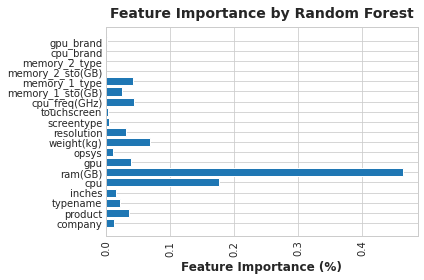

In [282]:
plt.barh(rf.feature_names,rf.feature_importances_)
plt.xticks(rotation=90);
plt.title('Feature Importance by Random Forest')
plt.xlabel('Feature Importance (%)')
plt.show()

# XGBoost

# OPTUNA Optimization

In [283]:
def objective(trial, X_train=X_train, X_val=X_val, y_train=y_train, y_val=y_val):
    dtrain = xgboost.DMatrix(X_train, label=y_train)
    dvalid = xgboost.DMatrix(X_val, label=y_val)

    param = {
        'objective' : 'reg:squarederror',
        'lambda': trial.suggest_loguniform('lambda', 1e-3, 5.0),
        'alpha': trial.suggest_loguniform('alpha', 1e-3, 5.0),
        'colsample_bytree': trial.suggest_categorical('colsample_bytree', [0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]),
        'subsample': trial.suggest_categorical('subsample', [0.4,0.5,0.6,0.7,0.8,1.0]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.001,0.01,0.05,0.1,0.2,0.25,0.3]),
        'n_estimators': trial.suggest_categorical('n_estimators', [300,400,500,1000,1500,2000,2500,3000]),
        'max_depth': trial.suggest_categorical('max_depth', [3,4,5,6,7]),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 100),
    }


    model = xgboost.XGBRegressor(**param)    
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=100, verbose=False)   
    preds = model.predict(X_val)
    rmse = mean_squared_error(y_val, preds, squared=False)

    return rmse

In [301]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))
print("  Params: ")

params = []

for key, value in trial.params.items():
    params.append(value)
    print("    {}: {}".format(key, value))

[I 2021-11-25 21:28:40,270] A new study created in memory with name: no-name-1ea086c9-43a7-417a-acc7-59eb90f91d2c
[I 2021-11-25 21:28:40,470] Trial 0 finished with value: 0.26415201631504054 and parameters: {'lambda': 0.005819175217536527, 'alpha': 0.003568337337840368, 'colsample_bytree': 0.3, 'subsample': 0.4, 'learning_rate': 0.05, 'n_estimators': 400, 'max_depth': 6, 'min_child_weight': 58}. Best is trial 0 with value: 0.26415201631504054.
[I 2021-11-25 21:28:40,734] Trial 1 finished with value: 0.2012815614292615 and parameters: {'lambda': 0.016474249654771223, 'alpha': 0.1568674442841794, 'colsample_bytree': 0.6, 'subsample': 0.6, 'learning_rate': 0.25, 'n_estimators': 400, 'max_depth': 6, 'min_child_weight': 53}. Best is trial 1 with value: 0.2012815614292615.
[I 2021-11-25 21:28:40,971] Trial 2 finished with value: 3.8652110381778315 and parameters: {'lambda': 0.010284755392278775, 'alpha': 2.549039425608574, 'colsample_bytree': 0.6, 'subsample': 0.5, 'learning_rate': 0.001, 'n

Number of finished trials:  100
Best trial:
  Value: 0.17150973558224925
  Params: 
    lambda: 0.002291372519483033
    alpha: 0.478012440080971
    colsample_bytree: 0.3
    subsample: 0.4
    learning_rate: 0.05
    n_estimators: 3000
    max_depth: 6
    min_child_weight: 1


In [302]:
params

[0.002291372519483033, 0.478012440080971, 0.3, 0.4, 0.05, 3000, 6, 1]

In [303]:
lambda_opt = params[0]
alpha_opt = params[1]
colsample_bytree_opt = params[2]
subsample_opt = params[3]
learning_rate_opt = params[4]
n_estimators_opt = params[5]
max_depth_opt = params[6]
min_child_weight_opt = params[7]

# XGBoost Optimization with OPTUNA

In [304]:
xgb = XGBRegressor(reg_lambda = lambda_opt,
                   alpha = alpha_opt,
                   colsample_bytree = colsample_bytree_opt,
                   subsample_opt = subsample_opt,
                   learning_rate = learning_rate_opt,
                   n_estimators = n_estimators_opt,
                   max_depth = max_depth_opt,
                   min_child_weight = min_child_weight_opt)

In [305]:
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], early_stopping_rounds=50, verbose=0)

[21:29:42] WARNING: ../src/learner.cc:576: 
Parameters: { "subsample_opt" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.




XGBRegressor(alpha=0.478012440080971, base_score=0.5, booster='gbtree',
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.3,
             enable_categorical=False, gamma=0, gpu_id=-1, importance_type=None,
             interaction_constraints='', learning_rate=0.05, max_delta_step=0,
             max_depth=6, min_child_weight=1, missing=nan,
             monotone_constraints='()', n_estimators=3000, n_jobs=2,
             num_parallel_tree=1, predictor='auto', random_state=0,
             reg_alpha=0.478012443, reg_lambda=0.002291372519483033,
             scale_pos_weight=1, subsample=1, subsample_opt=0.4,
             tree_method='exact', validate_parameters=1, verbosity=None)

In [306]:
y_pred_xgb = xgb.predict(X_test) 

In [307]:
mse_xgb = mean_squared_error(np.exp(y_test), np.exp(y_pred_xgb))

In [308]:
print("RMSE with XGBoost : {:.2f} $".format(np.round(np.sqrt(mse_xgb),2)))

RMSE with XGBoost : 241.30 $


In [309]:
print("R2 with XGBoost: {:.2f} % ".format(np.round(r2_score(y_test, y_pred_xgb),4)*100))

R2 with XGBoost: 92.72 % 


In [310]:
xgb.feature_names = feature_name_list

# Results Summary

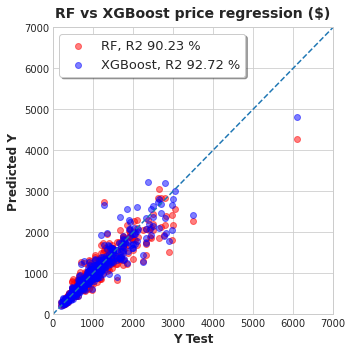

In [311]:
plt.figure(figsize = (5,5))
plt.scatter(np.exp(y_test), np.exp(y_pred_rf), alpha=0.5, color='red',label='RF, R2 {:.2f} %'.format(r2_score(y_test, y_pred_rf)*100))
plt.scatter(np.exp(y_test), np.exp(y_pred_xgb), alpha=0.5, color='blue',label='XGBoost, R2 {:.2f} %'.format(r2_score(y_test, y_pred_xgb)*100))
plt.plot([0, 7000], [0, 7000], linestyle='--')
plt.axis([0, 7000, 0, 7000])
plt.xlabel('Y Test')
plt.ylabel('Predicted Y')
plt.title('RF vs XGBoost price regression ($)')
plt.legend(loc='upper left', ncol=1, fontsize=13, fancybox=True, shadow=True, frameon=True)
plt.show()

In [312]:
print("RMSE using RF: {:.2f} $ ".format(np.sqrt(mse_rf)))
print("RMSE with XGBoost : {:.2f} $".format(np.sqrt(mse_xgb)))

RMSE using RF: 275.06 $ 
RMSE with XGBoost : 241.30 $


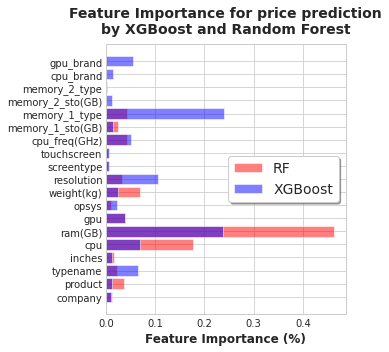

In [313]:
plt.figure(figsize=(5,5))
plt.barh(rf.feature_names,rf.feature_importances_, alpha=0.5, label='RF', color='red')
plt.barh(xgb.feature_names,xgb.feature_importances_, alpha=0.5, label='XGBoost', color='blue')
plt.legend(loc='center right',ncol=1, fontsize=14, fancybox=True, shadow=True, frameon=True)
plt.title('Feature Importance for price prediction\nby XGBoost and Random Forest')
plt.xlabel('Feature Importance (%)')
plt.show()

We can see that RF chose RAM, CPU, weight and product(name) as the most important features.<br>
In the case of XGBoost, the most important features are memory_1_type, RAM, resolution, cpu, typename and gpu brand.<br>
It is also worth noticing XGBoost didnt give as much importance to RAM and CPU as RF did. It spreaded more the feature importance among other features.

## Feature Importance by XGBoost (ordered)

In [314]:
xgb.feature_names = df1.drop('price', axis = 1).columns

In [315]:
feat_df= pd.DataFrame({'feature': xgb.feature_names,'importance':xgb.feature_importances_})

Then, I will sort it by 'importance', creating a new sorted dataframe by importance

In [316]:
sorted_df=feat_df.sort_values('importance', ascending=False)

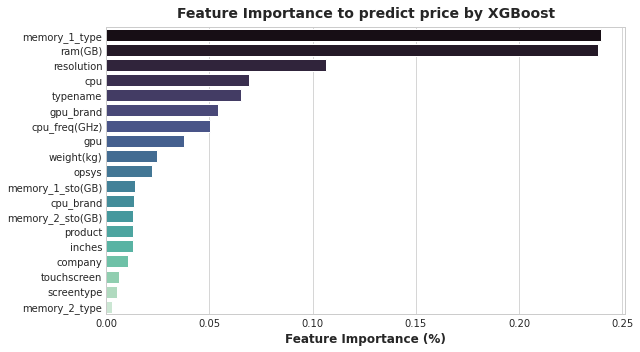

In [317]:
plt.figure(figsize=(9,5))
sns.barplot(x='importance', y='feature', data=sorted_df, palette='mako')
plt.title('Feature Importance to predict price by XGBoost')
plt.xlabel('Feature Importance (%)')
plt.ylabel('')
plt.show()

**Thank you very much for reading my notebook ! Let me know if you have questions or you want me to check out your works ! :)**